
---
date: "2026-09-08"
date-modified: last-modified
format:
  html:
    toc: true
---



# Bootstrap Aggregation (Bagging) and Random Forests

While individual [Decision Trees](decision-trees.ipynb) are intuitive, easily visualized, and mirror human decision-making, their practical utility as standalone predictors is severely constrained by **high variance**. A small perturbation in the training sample often produces a radically different sequence of splits. 

To overcome this limitation, **ensemble learning** combines multiple simple "weak learners" (trees with high variance but low bias) to produce a collective consensus model whose prediction variance is drastically reduced. This note develops the mathematical theory of **Bootstrap Aggregation (Bagging)**, derives the exact probability underlying **Out-of-Bag (OOB)** error estimation, formalizes **Variable Importance**, and proves how **Random Forests** overcome Bagging's fundamental correlation bottleneck through **tree decorrelation**.

---

## 1\. Ensemble Philosophy & The High Variance of Decision Trees

::: {#def-ensemble-weak-learner}
## Ensemble Method and Weak Learners
An **ensemble method** combines a collection of base models $\{f_1(\mathbf{x}), f_2(\mathbf{x}), \dots, f_B(\mathbf{x})\}$ to obtain a single consensus predictive model $f_{\text{ens}}(\mathbf{x})$. 

Individual building-block models are termed **weak learners** if their standalone predictive performance is modest, but their combined consensus achieves high accuracy and robust generalization.
:::

### 1.1\. The Instability and High Variance of Trees

Consider training a decision tree on a sample $\mathcal{D}_1$ drawn from population $\mathcal{P}$. The tree might select predictor $X_1$ at the root, followed by $X_2$ and $X_5$. If we draw another sample $\mathcal{D}_2$ from the exact same population $\mathcal{P}$, the tree may split first on $X_3$, followed by $X_1$, completely altering the tree topology and predictions.

By contrast, low-variance models like [Linear Regression](linear-regression.ipynb) yield stable coefficient planes across different samples (provided $n \gg p$). Full-grown, unpruned decision trees have low bias because they adapt flexibly to local structures, but their variance is very high.

### 1.2\. Statistical Foundation: Variance Reduction by Averaging

::: {#prp-variance-reduction}
## Variance Reduction of Independent Estimators
Let $Z_1, Z_2, \dots, Z_B$ be $B$ independent and identically distributed random variables, each with finite [variance](variance.ipynb) $\text{Var}(Z_b) = \sigma^2$. The variance of the sample average $\bar{Z} = \frac{1}{B} \sum_{b=1}^B Z_b$ satisfies:

$$
\text{Var}(\bar{Z}) = \text{Var}\left( \frac{1}{B} \sum_{b=1}^B Z_b \right) = \frac{1}{B^2} \sum_{b=1}^B \text{Var}(Z_b) = \frac{B \sigma^2}{B^2} = \frac{\sigma^2}{B}
$$
:::

::: {.callout-note}
## Intuition: The Averaging Principle
Averaging a set of independent observations strictly reduces variance by a factor of $1/B$ while leaving the expected value (bias) unchanged. Therefore, if we had access to $B$ separate training sets from the population, fitting a deep tree $\hat{f}^b(\mathbf{x})$ to each and averaging their predictions:
$$
\hat{f}_{\text{avg}}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^B \hat{f}^b(\mathbf{x})
$$
would retain the low bias of deep trees while crushing the variance down toward zero.
:::



## 2\. Bootstrap Aggregation (Bagging)

In real-world applications, we do not have access to $B$ independent training sets from the population; we possess only a single training dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$. 

**Bootstrap Aggregation (Bagging)** bypasses this limitation by using the [Bootstrap](sampling-with-replacement.ipynb) to generate $B$ synthetic training sets through repeated resampling.

::: {.callout-note}
## Intuition: The Box with Replacement Analogy
Imagine placing all $n$ training observations into a box. To create a bootstrap dataset $\mathcal{D}^{*b}$, draw an observation at random, record it, and place it back into the box. Repeat this draw $n$ times. Because sampling occurs **with replacement**, some observations appear multiple times while others are omitted entirely. Repeating this process $B$ times creates $B$ distinct datasets of size $n$.
:::

::: {#def-bagging-algorithm}
## Bagging Algorithm for Regression and Classification
Let $\mathcal{D}$ be a training set of size $n$.

1. For $b = 1, 2, \dots, B$:
   - Generate a bootstrap sample $\mathcal{D}^{*b}$ of size $n$ by sampling from $\mathcal{D}$ uniformly at random with replacement.
   - Train an unpruned, deep decision tree $\hat{f}^{*b}(\mathbf{x})$ on $\mathcal{D}^{*b}$.
2. Combine the $B$ tree models into an aggregate prediction:
   - **For Regression ($Y \in \mathbb{R}$):** Compute the arithmetic mean:
     $$
     \hat{f}_{\text{bag}}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^B \hat{f}^{*b}(\mathbf{x})
     $$
   - **For Classification ($Y \in \{1, \dots, K\}$):** Record the class predicted by each of the $B$ trees and take a **majority vote**:
     $$
     \hat{y}_{\text{bag}}(\mathbf{x}) = \arg\max_{k \in \{1, \dots, K\}} \sum_{b=1}^B \mathbf{1}_{\{\hat{f}^{*b}(\mathbf{x}) = k\}}
     $$
:::

### 2.1\. Behavior as $B \to \infty$

Unlike [Boosting](boosting.ipynb), the number of trees $B$ is not a critical tuning parameter that risks overfitting. Because each tree is fitted to an independent bootstrap sample and their predictions are averaged, increasing $B$ does not increase the flexibility of the ensemble. In practice, choosing $B$ sufficiently large (e.g., $B = 100$ to $500$) allows the variance and test error to settle to their asymptotic limit.



## 3\. Out-of-Bag (OOB) Error Estimation

A remarkable property of Bagging is that the test error of the ensemble can be estimated directly without performing separate cross-validation or withholding a validation set, using **Out-of-Bag (OOB)** samples.

::: {#thm-oob-probability}
## Asymptotic Probability of Out-of-Bag Observations
When drawing a bootstrap sample of size $n$ with replacement from a dataset of size $n$, the probability that any specific observation $i$ is omitted from the sample converges to $1/e \approx 0.368 \approx 1/3$ as $n \to \infty$.
:::

::: {.callout-tip collapse="true"}
## Proof of OOB Probability Derivation
Consider a specific observation $\mathbf{x}_i$. In each random draw with replacement, the probability that observation $i$ is selected is $\frac{1}{n}$. Consequently, the probability that observation $i$ is *not* selected in a single draw is:

$$
P(i \text{ not chosen in 1 draw}) = 1 - \frac{1}{n}
$$

Since the $n$ draws comprising a bootstrap sample are mutually independent, the probability that observation $i$ is not chosen in any of the $n$ draws is:

$$
P(i \notin \mathcal{D}^{*b}) = \left( 1 - \frac{1}{n} \right)^n
$$

Using the classical limit definition of the exponential function $\lim_{n \to \infty} (1 + x/n)^n = e^x$ with $x = -1$:

$$
\lim_{n \to \infty} \left( 1 - \frac{1}{n} \right)^n = e^{-1} = \frac{1}{e} \approx 0.367879...
$$

Thus, for moderately large $n$, roughly two-thirds ($63.2\%$) of the unique training observations are included in each bootstrap tree, and approximately one-third ($36.8\%$) are left out as out-of-bag observations. $\blacksquare$
:::

### 3.1\. The OOB Error Procedure

Because each tree omits roughly $1/3$ of the training observations, any given observation $i$ is out-of-bag for approximately $B/3$ of the $B$ trees:

1. For each observation $i \in \{1, \dots, n\}$, identify the subset of trees $\mathcal{T}_i \subset \{1, \dots, B\}$ that did not utilize observation $i$ during training ($|\mathcal{T}_i| \approx B/3$).
2. Form a single consensus prediction $\hat{y}_{i, \text{OOB}}$ for observation $i$ using only the trees in $\mathcal{T}_i$:
   - Regression: Average the predictions of trees in $\mathcal{T}_i$.
   - Classification: Take the majority vote among trees in $\mathcal{T}_i$.
3. Compute the overall OOB error across all $n$ observations:
   $$
   \text{OOB MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_{i, \text{OOB}})^2
   $$

::: {.callout-note}
## Intuition: Free Validation Without Cross-Validation
Because observation $i$ was never seen by any tree in $\mathcal{T}_i$, $\hat{y}_{i, \text{OOB}}$ is a genuine out-of-sample prediction. For sufficiently large $B$, the OOB error rate is virtually identical to Leave-One-Out Cross-Validation (LOOCV) error, providing an essentially free diagnostic for model tuning.
:::



## 4\. Variable Importance Measures

A major disadvantage of bagging an ensemble of hundreds of trees is the loss of direct graphical interpretability. It is no longer possible to summarize the decision process with a single clean diagram. To restore interpretability, we compute **Variable Importance Measures** across the ensemble:

::: {#def-variable-importance}
## Ensemble Variable Importance
Let $X_j$ be a predictor variable. Its importance across an ensemble of $B$ trees is measured by accumulating the impurity reduction attributable to splits on $X_j$:

* **Regression Trees (RSS Criterion):** Sum the total amount that the Residual Sum of Squares (RSS) is decreased due to splits over predictor $X_j$, averaged across all $B$ trees:
  $$
  \mathcal{I}(X_j) = \frac{1}{B} \sum_{b=1}^B \sum_{t \in T_b: v(t) = j} \Delta \text{RSS}(t)
  $$
  where $v(t) = j$ denotes that internal node $t$ splits on variable $X_j$, and $\Delta \text{RSS}(t) = \text{RSS}(t) - (\text{RSS}(t_L) + \text{RSS}(t_R))$.

* **Classification Trees (Gini Criterion):** Sum the total decrease in the Gini index resulting from splits on $X_j$, averaged across all $B$ trees:
  $$
  \mathcal{I}(X_j) = \frac{1}{B} \sum_{b=1}^B \sum_{t \in T_b: v(t) = j} \Delta G(t)
  $$

In reporting, importances are typically scaled relative to the most important predictor, with the maximum value set to $100\%$.
:::



## 5\. Random Forests & The Tree Decorrelation Mechanism

Although Bagging reduces variance compared to a single tree, it suffers from a subtle but fundamental vulnerability: **tree correlation**.

::: {.callout-warning}
## The Failure Mode of Bagging: Dominant Features
Suppose a dataset contains one exceptionally strong predictor alongside several moderately strong predictors. In Bagging, because every tree considers all $p$ features at every split, virtually every tree will select the dominant predictor at the top root split.

Consequently, all $B$ trees develop similar topologies, and their predictions become **highly correlated**. Averaging highly correlated random variables yields only a modest reduction in variance!
:::

### 5.1\. Mathematical Proof: Variance of Correlated Estimators

::: {#prp-correlated-variance}
## Variance of an Average of Correlated Random Variables
Let $T_1, T_2, \dots, T_B$ be $B$ identically distributed random variables, each with variance $\text{Var}(T_b) = \sigma^2$, and positive pairwise correlation $\text{Corr}(T_b, T_{b'}) = \rho > 0$ for all $b \neq b'$. The variance of their ensemble average $\bar{T} = \frac{1}{B} \sum_{b=1}^B T_b$ is:

$$
\text{Var}(\bar{T}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Correlated Variance Formula
By the bilinear expansion of the variance of a linear combination:
$$
\begin{aligned}
\text{Var}(\bar{T}) &= \text{Var}\left( \frac{1}{B} \sum_{b=1}^B T_b \right) = \frac{1}{B^2} \sum_{b=1}^B \sum_{b'=1}^B \text{Cov}(T_b, T_{b'}) \\
&= \frac{1}{B^2} \left[ \sum_{b=1}^B \text{Var}(T_b) + \sum_{b=1}^B \sum_{b' \neq b} \text{Cov}(T_b, T_{b'}) \right] \\
&= \frac{1}{B^2} \left[ B \sigma^2 + B(B - 1) \rho \sigma^2 \right] \\
&= \frac{\sigma^2}{B} + \frac{B - 1}{B} \rho \sigma^2 \\
&= \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2
\end{aligned}
$$
Taking the limit as the number of trees $B \to \infty$:
$$
\lim_{B \to \infty} \text{Var}(\bar{T}) = \rho \sigma^2
$$
When trees are correlated ($\rho > 0$), no matter how large $B$ becomes, the ensemble variance cannot drop below $\rho \sigma^2$. If $\rho$ is large, bagging fails to achieve significant variance reduction. $\blacksquare$
:::

### 5.2\. The Random Forest Solution: Random Feature Subspaces

**Random Forests** overcome this correlation floor through a brilliant structural constraint: **tree decorrelation**.

::: {#def-random-forest}
## Random Forest Splitting Rule
Like Bagging, a Random Forest builds $B$ decision trees on bootstrapped training samples. However, each time a split in a tree is evaluated, **the algorithm is restricted to consider only a random sample of $m$ candidate predictors** chosen from the full set of $p$ predictors.

The split is permitted to choose only from among these $m$ features. A fresh, independent sample of $m$ predictors is taken at every split.

Standard default choices for $m$ are:
* **Classification:** $m \approx \sqrt{p}$
* **Regression:** $m \approx p/3$
:::

::: {.callout-note}
## Intuition: How Feature Sub-sampling Decorrelates Trees
On average, a fraction $(p - m)/p$ of the splits will not even consider the dominant predictor! Other moderately strong predictors are forced into top-level splits, generating trees with diverse structures and substantially lower pairwise correlation $\rho$. By driving $\rho \to 0$, the residual variance $\rho \sigma^2$ collapses, enabling the ensemble average to achieve far greater accuracy than standard Bagging.

When $m = p$, a Random Forest is exactly equivalent to Bagging.
:::

### 5.3\. High-Dimensional Biological Example ($p \gg n$)

The lecture highlights a high-dimensional cancer gene expression dataset where $p = 4{,}718$ genes were measured on $n = 349$ patients across 15 cancer classes. In such wide ($p \gg n$) settings, linear regression overfits completely. Setting $m = \sqrt{p} \approx 22$ forces the trees to explore diverse molecular signatures, driving test classification error from $45.7\%$ (single tree) down to $\approx 20\%$, significantly outperforming Bagging ($m = p$).

---

## 6\. Numerical Simulation of Ensemble Variance & OOB Convergence

Below, we simulate:
1. The theoretical ensemble variance as a function of the number of trees $B$ across varying tree correlation coefficients $\rho \in \{0.0, 0.2, 0.5, 0.8\}$.
2. The convergence of the OOB omission probability $(1 - 1/n)^n$ to $1/e$ as sample size $n$ increases.


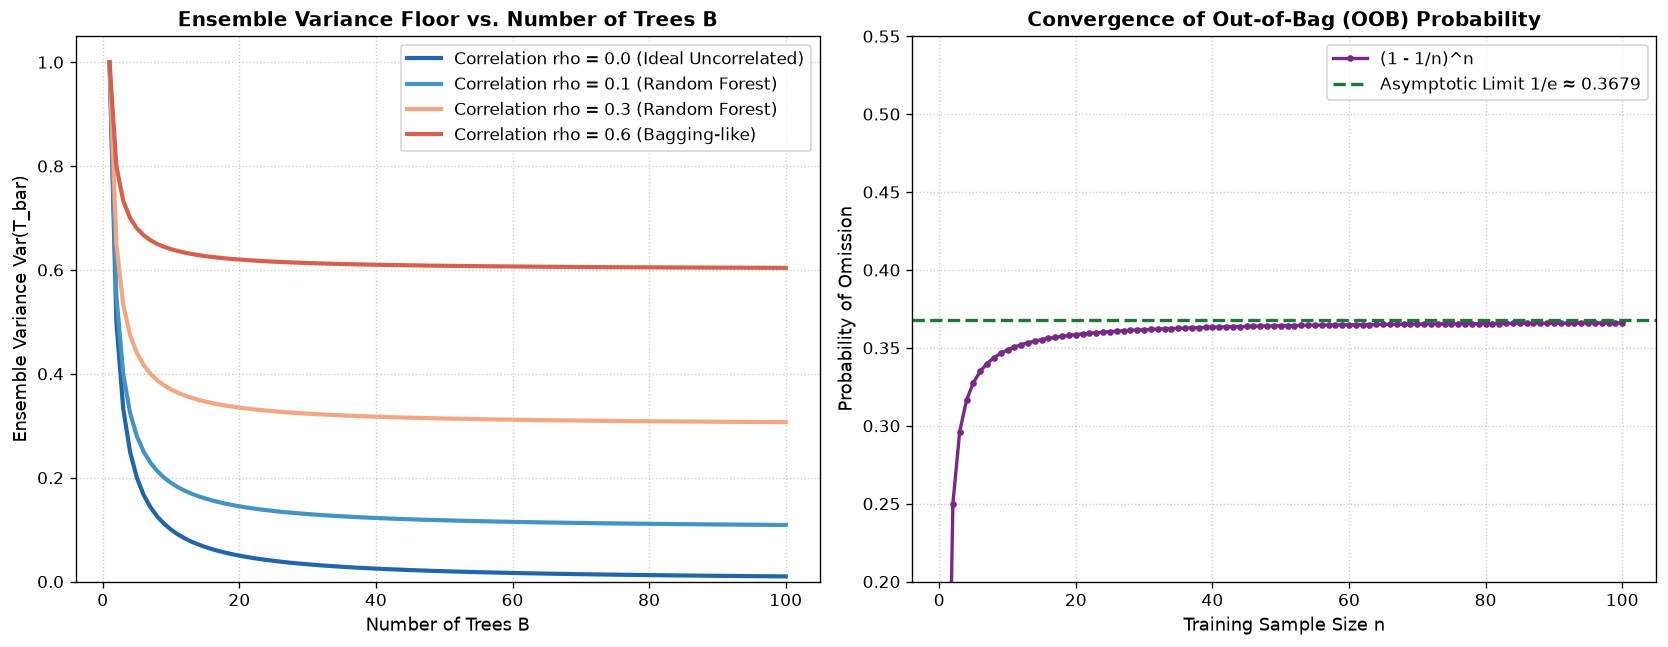

In [1]:

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

# -----------------------------------------------------
# Panel 1: Ensemble Variance vs. Number of Trees B
# -----------------------------------------------------
ax1 = axes[0]
B = np.arange(1, 101)
sigma2 = 1.0
correlations = [0.0, 0.1, 0.3, 0.6]
colors = ['#2166ac', '#4393c3', '#f4a582', '#d6604d']

for rho, col in zip(correlations, colors):
    var_ensemble = rho * sigma2 + ((1.0 - rho) / B) * sigma2
    label = f'Correlation rho = {rho}' + (' (Ideal Uncorrelated)' if rho == 0 else (' (Bagging-like)' if rho >= 0.5 else ' (Random Forest)'))
    ax1.plot(B, var_ensemble, label=label, color=col, linewidth=2.5)

ax1.set_title("Ensemble Variance Floor vs. Number of Trees B", fontsize=12, fontweight='bold')
ax1.set_xlabel("Number of Trees B", fontsize=11)
ax1.set_ylabel("Ensemble Variance Var(T_bar)", fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.legend(frameon=True, facecolor='white', loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------
# Panel 2: Convergence of OOB Omission Probability to 1/e
# -----------------------------------------------------
ax2 = axes[1]
n_vals = np.arange(1, 101)
p_oob = (1.0 - 1.0 / n_vals) ** n_vals
limit_val = 1.0 / np.e

ax2.plot(n_vals, p_oob, 'o-', color='#762a83', markersize=3, linewidth=2, label='(1 - 1/n)^n')
ax2.axhline(limit_val, color='#1b7837', linestyle='--', linewidth=2, label='Asymptotic Limit 1/e ≈ 0.3679')

ax2.set_title("Convergence of Out-of-Bag (OOB) Probability", fontsize=12, fontweight='bold')
ax2.set_xlabel("Training Sample Size n", fontsize=11)
ax2.set_ylabel("Probability of Omission", fontsize=11)
ax2.set_ylim(0.2, 0.55)
ax2.legend(frameon=True, facecolor='white', loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
